<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 2. Trabajando con redes neuronales y Deep Learning</header1></left>

Presentado por: David Vicente Mpya  <br>
Fecha: 22/05/2026

# Importación de librerias necesarias

# Parte II. Clasificación

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Para la red neuronal
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Para Random Forest
from sklearn.ensemble import RandomForestClassifier

## Cargar el Dataset

Cargamos los datos del dataset siguiendo las indicaciones de la UCI (https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
dry_bean = fetch_ucirepo(id=602) 
  
# Obtengo los datos en forma de dataframes de pandas
X = dry_bean.data.features # Datos de entrada
y = dry_bean.data.targets  # Datos variable objetivo

# La UCI divide los datos en entrada y objetivo por la propia forma en la que funciona su API
# Voy a juntarlos en un solo dataframe para el EDA, ya que es más facil trabajar con un solo dataframe
df = pd.concat([X, y], axis=1)
  
df.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Descripción de la fuente del Dataset

El dataset que vamos a utilizar contiene datos recogidos de varios tipos de judías. Estos datos se corresponden con las características físicas de la planta como la longitud de la vaina o la circunferencia de la judía. Este dataset pertenece a la Universidad Californiana de Irvine (UCI) como parte de su Machine Learning Repository, y se encuentra bajo licencia de Creative Commons.

- **`Area`**: Área de la zona del judía; número de píxeles dentro de sus límites
- **`Perimeter`**: Perímetro del judía; se define como la longitud de su borde
- **`MajorAxisLength`**: Longitud del eje mayor; distancia entre los extremos de la línea más larga que se puede trazar en el judía
- **`MinorAxisLength`**: Longitud del eje menor; línea más larga perpendicular al eje principal del judía
- **`AspectRatio`**: Relación de aspecto entre la longitud del eje mayor y el eje menor
- **`Eccentricity`**: Excentricidad de la elipse que tiene los mismos momentos que la región del judía
- **`ConvexArea`**: Área convexa; número de píxeles en el polígono convexo más pequeño que contiene el judía
- **`EquivDiameter`**: Diámetro equivalente; diámetro de un círculo con el mismo área que el judía
- **`Extent`**: Proporción entre los píxeles del rectángulo delimitador y el área del judía
- **`Solidity`**: Solidez o convexidad; relación entre el área del judía y su envoltura convexa
- **`Roundness`**: Redondez del objeto, calculada con la fórmula (4piA)/(P^2)
- **`Compactness`**: Compacidad; mide cuán compacto o redondo es el objeto
- **`ShapeFactor1`**: Factor de forma 1; métrica derivada de la forma del objeto (relación geométrica)
- **`ShapeFactor2`**: Factor de forma 2; otra medida derivada de la forma del objeto
- **`ShapeFactor3`**: Factor de forma 3; indicador relacionado con la complejidad de la forma
- **`ShapeFactor4`**: Factor de forma 4; medida adicional de características geométricas del objeto
- **`Class`**: Clase objetivo; tipo de judía (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz y Sira)

## Explique el problema a resolver. 
El problema que se quiere resolver es la **clasificación automática del tipo de judía** a partir de características obtenidas de imágenes de judías. Se trata de un problema de **clasificación multiclase**, ya que la variable objetivo puede tomar siete categorías distintas (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz y Sira), y el objetivo es asignar cada muestra a una de ellas.

La variable objetivo es **`Class`**, mientras que las variables de entrada describen propiedades morfológicas de la judía como el área, perímetro, ejes principales, compacidad, redondez y otros factores de forma derivados.

La utilidad de este problema radica en su aplicación en **agricultura e industria alimentaria**, donde un modelo de clasificación automática puede mejorar la eficiencia en la selección y control de calidad de judías, reduciendo la intervención manual.

Las relaciones que se buscan estudiar son cómo las características de forma y tamaño influyen en la clasificación de las distintas variedades de judía, y qué variables son más relevantes para diferenciarlas.

Para resolverlo se pueden utilizar modelos de clasificación como Random Forest, SVM o redes neuronales, evaluando su rendimiento mediante métricas como accuracy y F1-score.

## Caracterización del Dataset

In [4]:
# Generamos estadísticas descriptivass de los datos
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [5]:
# Vemos el número de instancias que tiene el set
df.shape

(13611, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [7]:
# Visualizamos el total de valores nulos de cada variable del dataset
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [8]:
print(df["Class"].unique())
# Son 7 clases en total, cada una de ellas es el nombre (string) de un tipo de judía

['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


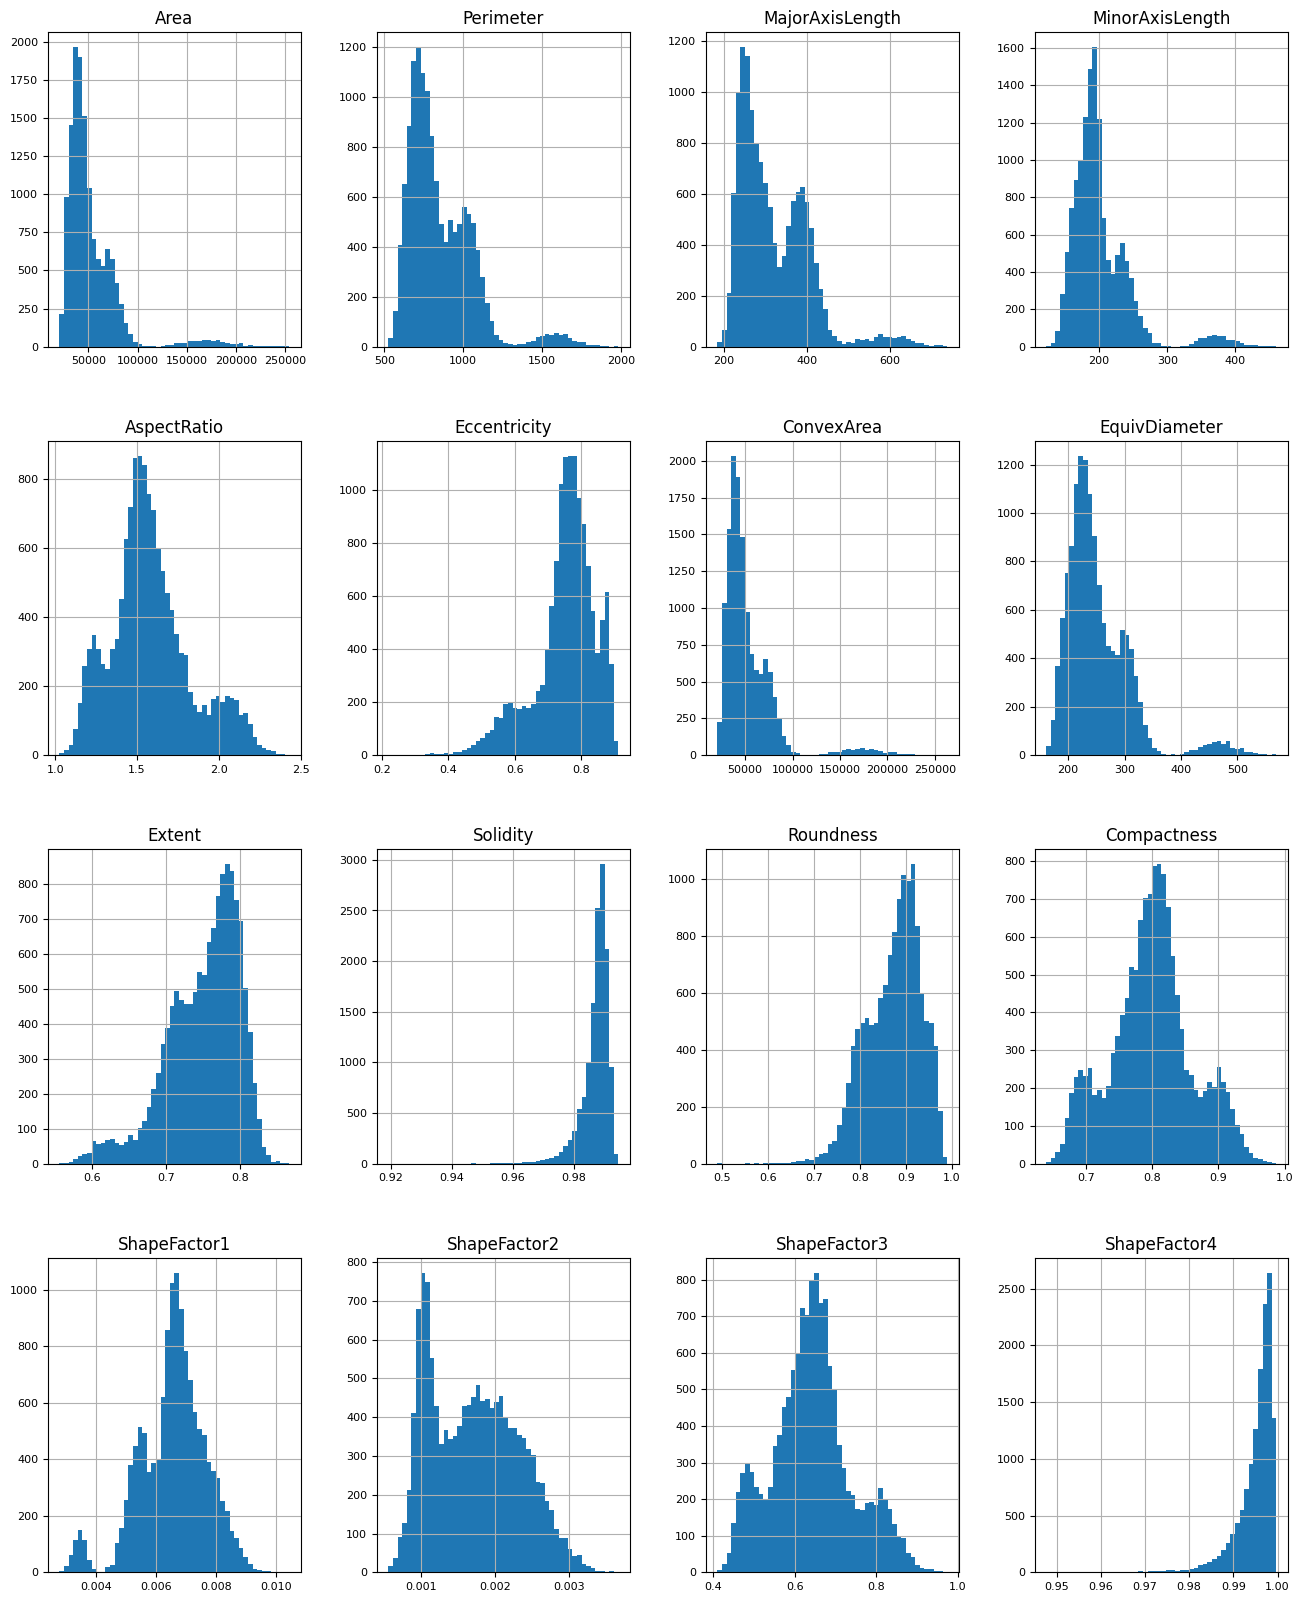

In [9]:
# Dibujamos los histogramas de las variables numéricas para conocer su distribución
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

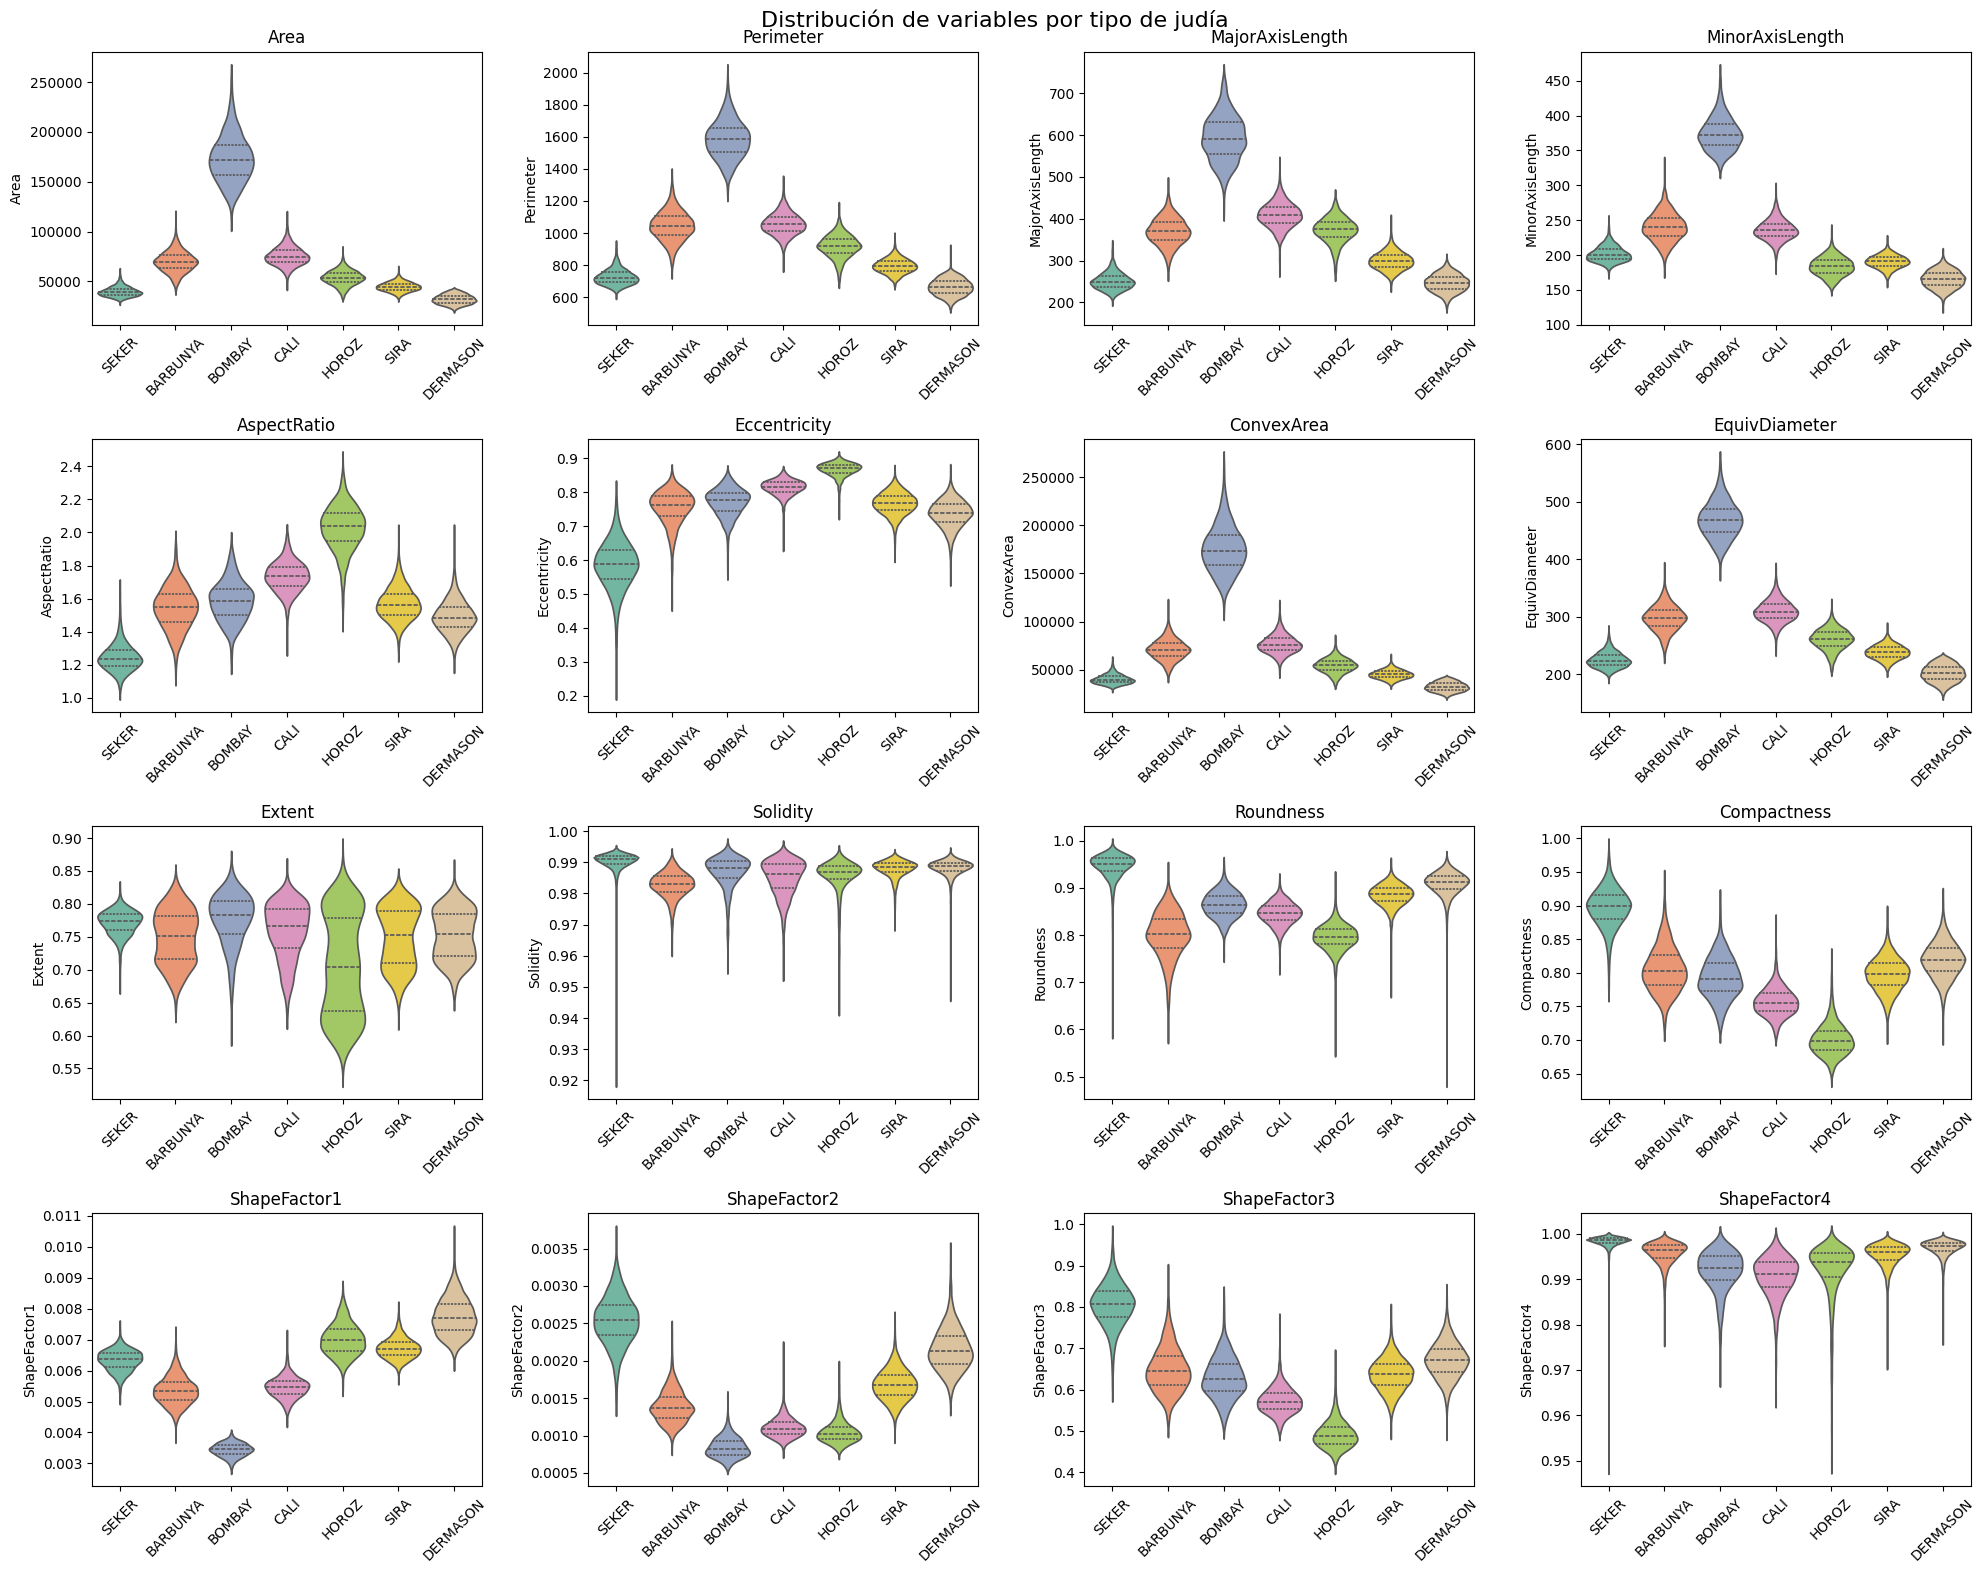

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.violinplot(
        data=df, 
        x="Class", 
        y=col, 
        ax=axes[i],
        hue="Class",
        legend=False,
        palette="Set2",
        inner="quartile"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Distribución de variables por tipo de judía", fontsize=16)
plt.tight_layout()

# Guardar la imagen
plt.savefig("violinplots.png", dpi=150, bbox_inches="tight")
plt.show()

La variable más discriminante es el **tamaño del grano**: `Area`, `Perimeter`, `ConvexArea` y `EquivDiameter` muestran que la variedad **Bombay** se separa del resto con un tamaño mucho mayor, mientras que **Dermason** ocupa el extremo opuesto con los granos más pequeños. Esto sugiere que el tamaño por sí solo es suficiente para identificar estas dos variedades con alta fiabilidad.

En cuanto a la **forma del grano,** `AspectRatio` y `Eccentricity` revelan que **Seker** es la variedad más redondeada, con valores de AspectRatio concentrados en torno a *1.2*, mientras que **Horoz** es la más alargada, con valores que alcanzan *2.2*. Esta diferencia es relevante ya que permite al modelo distinguir estas dos variedades incluso cuando su tamaño es similar. Por su parte, `ShapeFactor1` y `ShapeFactor2` complementan esta información, mostrando patrones diferenciados especialmente para **Bombay** y **Dermason**.

Como apunte final, destacan `Solidity` y `ShapeFactor4` como las variables de menor utilidad para la clasificación, ya que todos los violines aparecen comprimidos en rangos muy estrechos (*0.97-1.00* y *0.96-1.00* respectivamente) sin diferencias apreciables entre clases. De forma similar, `Extent` muestra una alta varianza dentro de cada clase, especialmente en **Horoz**, lo que dificulta su uso como variable discriminante. El mayor reto para el modelo será distinguir entre **Sira**, **Dermason** y **Cali**, cuyas distribuciones se solapan en la mayoría de variables.

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

Los datos ya se encuentran seàrados en variables de entrada (`X`) y variable objetivo (`y`). El dataset no cuenta con valores nulos y todas las variables pueden afectar el resultado de la predicción, por lo que no es mecesario deshacernos de ningún dato. Aún así, vamos a emplear **label encoding** para codificar la variable objetivo y poderla usar en los modelos de clasificación.

In [11]:
# Label Encoding para la variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
# values.ravel() convierte la columna almacenada en 'y', con forma de array 2D, en un array 1D con el que 'le' puede trabajar.

# Nromalizamos las variables de entrada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## División del dataset en datos de entrenamiento y datos de test 

In [12]:
# Dividimos el dataset en 80% entrenamiento y 20% test.
# Utilizamos stratify para mantener la proporción de clases en ambos subconjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Útil en modelos de clasificación multiclase
)

## Propuesta de arquitectura de red neuronal

La red neuronal propuesta para el problema de clasificación cuenta con la siguiente 
arquitectura:

* **Capa de entrada**: 16 neuronas, una por cada variable de entrada del dataset.

* **Primera capa oculta**: 128 neuronas con función de activación **ReLU**.

* **Segunda capa oculta**: 64 neuronas con función de activación **ReLU**.

* **Tercera capa oculta**: 32 neuronas con función de activación **ReLU**.

* **Capa de salida**: 7 neuronas, una por cada tipo de judía (Seker, Barbunya, 
Bombay, Cali, Dermason, Horoz y Sira), con función de activación **Softmax**, 
que convierte las salidas en probabilidades que suman 1, asignando cada muestra 
a la clase con mayor probabilidad.

In [13]:
# Número de neuronas de entrada y clase
n_inputs = X_train.shape[1]
n_clases = len(le.classes_)

# Arquitectura de la red
model = keras.Sequential([
    layers.Input(shape=(n_inputs,)),             # Capa de entrada
    
    layers.Dense(128, activation="relu"),        # Primera capa oculta
    layers.Dense(64, activation="relu"),         # Segunda capa oculta
    layers.Dense(32, activation="relu"),         # Tercera capa oculta

    layers.Dense(n_clases, activation="softmax") # Capa de salida: 7 neuronas con Softmax
])

In [14]:
# Resumen de la arquitectura
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,743 (49.78 KB)

 Trainable params: 12,743 (49.78 KB)

 Non-trainable params: 0 (0.00 B)

##  Ajuste de modelo de Clasificación RNA

In [15]:
# Compilar el modelo
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # para labels enteros
    metrics=["accuracy"]
)

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8620 - loss: 0.4468 - val_accuracy: 0.9252 - val_loss: 0.2223
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9196 - loss: 0.2210 - val_accuracy: 0.9137 - val_loss: 0.2227
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9259 - loss: 0.2082 - val_accuracy: 0.9376 - val_loss: 0.1949
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9266 - loss: 0.2004 - val_accuracy: 0.9320 - val_loss: 0.1980
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9268 - loss: 0.1966 - val_accuracy: 0.9279 - val_loss: 0.2044
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9289 - loss: 0.1931 - val_accuracy: 0.9233 - val_loss: 0.2008
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9292 - loss: 0.1934 - val_accuracy: 0.9348 - val_loss: 0.1914
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9313 - loss: 0.1884 - val_accu

## Evaluación de modelo RNA

### Visualice el progreso de entrenamiento del modelo y muestre las estadísticas de evaluación para los conjuntos de entrenamiento y validación.  

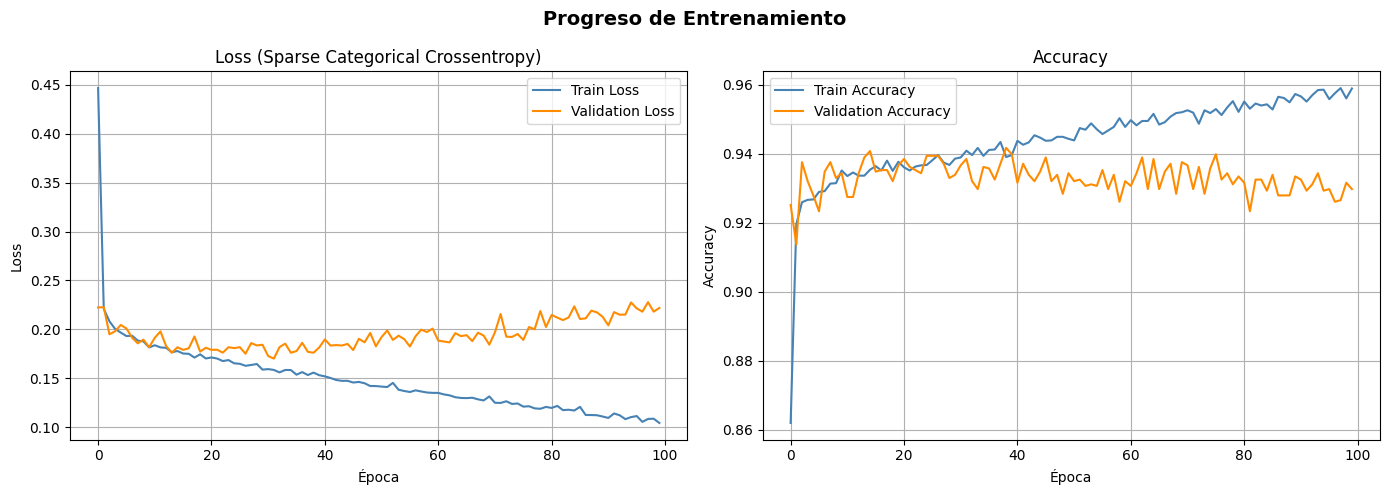

In [16]:
# Gráfica de progreso de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Progreso de Entrenamiento", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(history.history["loss"], label="Train Loss", color="steelblue")
axes[0].plot(history.history["val_loss"], label="Validation Loss", color="darkorange")
axes[0].set_title("Loss (Sparse Categorical Crossentropy)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history["accuracy"], label="Train Accuracy", color="steelblue")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", color="darkorange")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Evalúe los resultados  para el conjunto de test.

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.92      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.95      0.95      0.95       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.92      0.97      0.94       406
        SIRA       0.86      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



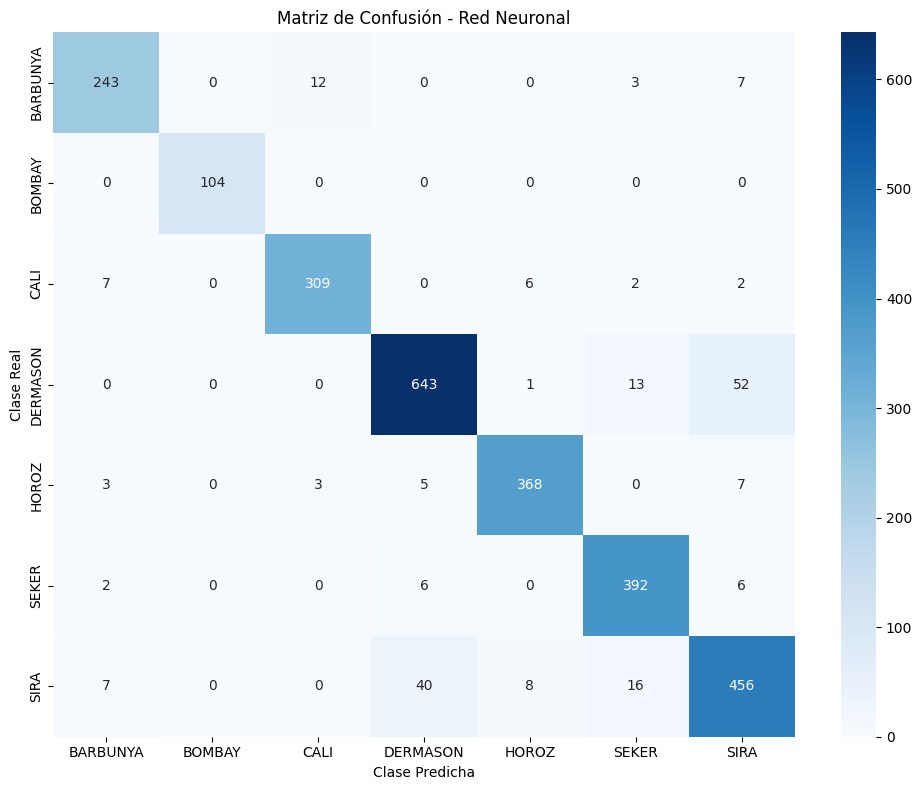

In [17]:
# Predicciones
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Métricas generales
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Matriz de Confusión - Red Neuronal")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.tight_layout()
plt.show()

Los resultados de la red neuronal sobre el conjunto de test son muy satisfactorios, alcanzando una **accuracy global del 92%**. 

Por clases, destaca **Bombay** con una precisión y recall perfectos (*1.00*), lo que confirma lo observado en los violin plots: su tamaño notablemente superior al resto la hace trivialmente identificable para el modelo. En el extremo opuesto, **Sira** es la clase más difícil de clasificar, con un F1-score de *0.85*, lo que también era esperable dado el solapamiento que mostraba con **Dermason** y **Cali** en el análisis exploratorio.

El resto de clases obtienen resultados muy consistentes, con F1-scores entre *0.91* (**Barbunya**) y *0.95* (**Horoz** y **Seker**), lo que indica que el modelo generaliza bien para la mayoría de variedades. La diferencia entre la macro average (*0.93*) y la weighted average (*0.92*) es mínima, lo que sugiere que el desbalance entre clases (Dermason tiene *709* instancias frente a las *104* de Bombay) no ha afectado significativamente al rendimiento del modelo.

## Ajuste de modelos de clasificación alternativos

In [18]:
# Definir y entrenar el modelo
rf_model = RandomForestClassifier(
    n_estimators=100,    # número de árboles
    max_depth=10,        # profundidad máxima de cada árbol
    min_samples_split=5, # mínimo de muestras para dividir un nodo
    min_samples_leaf=2,  # mínimo de muestras en cada hoja
    random_state=42      # semilla para reproducibilidad
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 0.9199

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.86      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



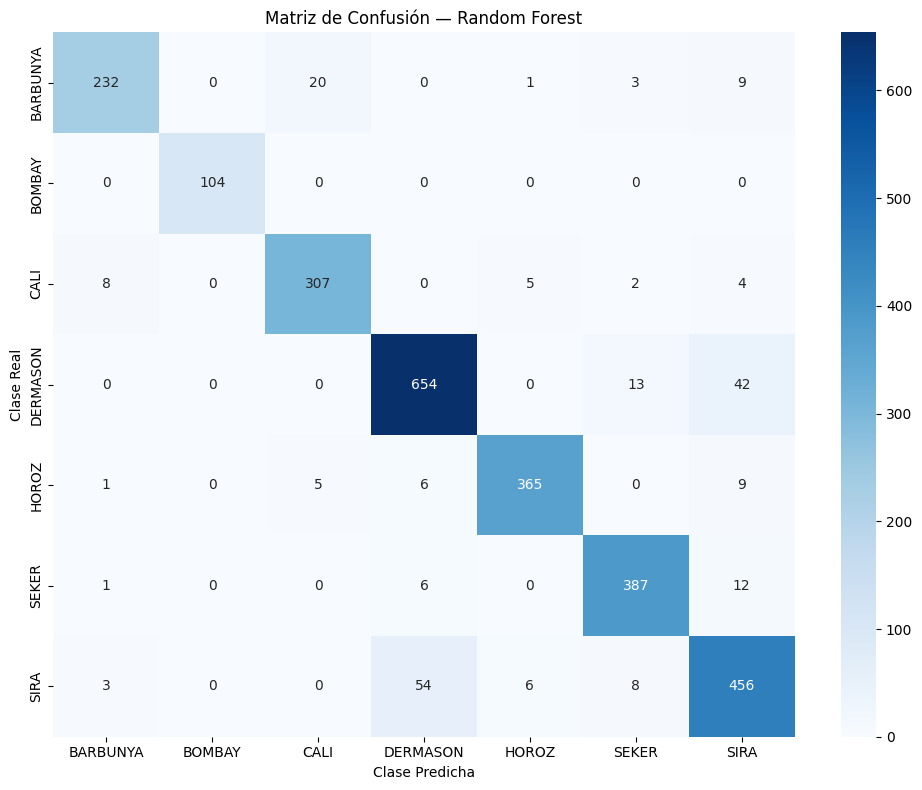

In [19]:
# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Matriz de Confusión — Random Forest")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.tight_layout()
plt.show()

## Comparación del desempeño de modelos

In [20]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla
comparacion = pd.DataFrame({
    "Modelo":       ["Red Neuronal", "Random Forest"],
    "Accuracy":     [accuracy_score(y_test, y_pred),
                     accuracy_score(y_test, y_pred_rf)],
    "F1 Macro":     [f1_score(y_test, y_pred, average="macro"),
                     f1_score(y_test, y_pred_rf, average="macro")],
    "F1 Weighted":  [f1_score(y_test, y_pred, average="weighted"),
                     f1_score(y_test, y_pred_rf, average="weighted")]
})

print(comparacion.to_string(index=False))

       Modelo  Accuracy  F1 Macro  F1 Weighted
 Red Neuronal  0.923614  0.935970     0.923587
Random Forest  0.919941  0.931608     0.919981


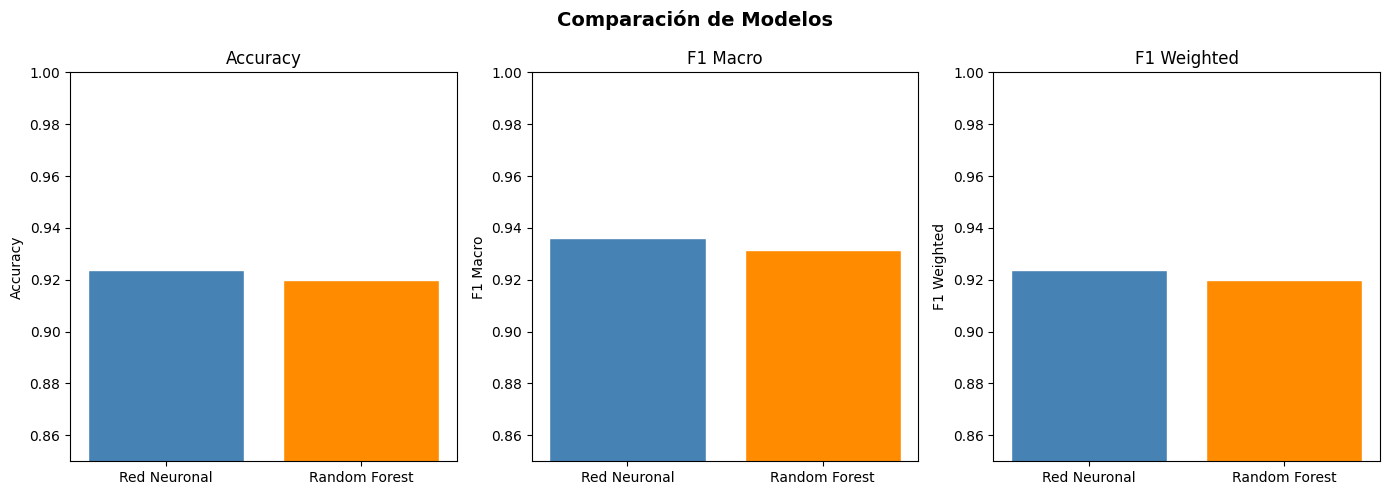

In [21]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparación de Modelos", fontsize=14, fontweight="bold")

modelos = ["Red Neuronal", "Random Forest"]
colores = ["steelblue", "darkorange"]

valores_rn = [
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred, average="macro"),
    f1_score(y_test, y_pred, average="weighted")
]
valores_rf = [
    accuracy_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf, average="macro"),
    f1_score(y_test, y_pred_rf, average="weighted")
]
metricas = ["Accuracy", "F1 Macro", "F1 Weighted"]

for i, metrica in enumerate(metricas):
    axes[i].bar(modelos, [valores_rn[i], valores_rf[i]],
                color=colores, edgecolor="white")
    axes[i].set_title(metrica)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_ylabel(metrica)

plt.tight_layout()
plt.show()

Ambos modelos obtienen resultados muy similares, con una **accuracy del 91%** y un F1-score macro de *0.92* y *0.91*. En este caso, la **red neuronal supera ligeramente al Random Forest** en casi todas las métricas.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Ambos modelos han obtenido resultados muy satisfactorios para el problema de clasificación de variedades de judía, con accuracies superiores al *90%* y F1-scores por encima de *0.93*. La red neuronal obtiene resultados algo mejores en todas las métricas, aunque las diferencias son tan pequeñas que ambos modelos pueden considerarse equivalentes para este problema.

La clase **Bombay** es clasificada perfectamente por ambos modelos (*1.00* en todas las métricas), confirmando lo observado en el EDA: su tamaño notablemente superior la hace fácilmente identificable. Por el contrario, **Sira** sigue siendo la clase más difícil, con F1-scores de *0.85* y *0.86*, debido a su solapamiento con **Dermason** y **Cali** en las variables de forma y tamaño.

En cuanto a cómo mejorar los resultados de la red neuronal, se podrían explorar el uso de **Early Stopping** para evitar el sobreajuste deteniendo el entrenamiento cuando el resultado deje de mejorar. También podemos desarrollar una arquitectura más profunda, mayor número de capas, y aumentar el número de epochs para mejorar el entrenamiento del modelo de red neuronal.